# `graph.py` 工作流可视化

本 Notebook 只还原 `src/agent/graph.py` 的图结构，不初始化 LLM、不读取 API Key，也不依赖 LangGraph 安装。任意 Python Jupyter 内核均可运行。

In [16]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'tests':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Python:', sys.executable)
print('项目根目录:', PROJECT_ROOT)


Python: F:\Software\Anaconda\envs\langgraph\python.exe
项目根目录: G:\大厂学习\minimind\langgraph


## 按照 `build_graph()` 描述拓扑

`agent` 有工具调用时进入 `tools`，否则结束；`tools` 执行完后返回 `agent`。

In [17]:
nodes = ['START', 'agent', 'tools', 'END']
edges = [
    ('START', 'agent', '入口'),
    ('agent', 'tools', '存在 tool_calls'),
    ('agent', 'END', '无 tool_calls'),
    ('tools', 'agent', '工具执行完成'),
]

print('节点:', nodes)
print('边:')
for source, target, condition in edges:
    print(f'  {source} -> {target}: {condition}')


节点: ['START', 'agent', 'tools', 'END']
边:
  START -> agent: 入口
  agent -> tools: 存在 tool_calls
  agent -> END: 无 tool_calls
  tools -> agent: 工具执行完成


## Mermaid 可视化

In [18]:
from IPython.display import Markdown, display

mermaid = '''flowchart TD
    START([START]) --> agent[agent\n调用带工具的 LLM]
    agent -->|存在 tool_calls| tools[tools\n执行设备或场景工具]
    agent -->|无 tool_calls| END([END])
    tools -->|工具执行完成| agent
'''
print(mermaid)
display(Markdown(f'```mermaid\n{mermaid}\n```'))


flowchart TD
    START([START]) --> agent[agent
调用带工具的 LLM]
    agent -->|存在 tool_calls| tools[tools
执行设备或场景工具]
    agent -->|无 tool_calls| END([END])
    tools -->|工具执行完成| agent



```mermaid
flowchart TD
    START([START]) --> agent[agent
调用带工具的 LLM]
    agent -->|存在 tool_calls| tools[tools
执行设备或场景工具]
    agent -->|无 tool_calls| END([END])
    tools -->|工具执行完成| agent

```

## 可选：保存 PNG

下面使用 Mermaid 在线渲染地址生成 PNG。如果网络不可用，前面的 Mermaid 源码仍然有效。

In [19]:
import base64
from IPython.display import Image, display

try:
    encoded = base64.urlsafe_b64encode(mermaid.encode('utf-8')).decode('ascii')
    display(Image(url=f'https://mermaid.ink/img/{encoded}'))
except Exception as exc:
    print('PNG 渲染失败，不影响 Mermaid 图。原因:', exc)

## 完整 Agent 工作流图

下面展示完整的智能家居 Agent 架构，包含：
- **记忆系统**：上下文同步、记忆检索、记忆推理
- **路由系统**：意图分类、规划决策
- **执行模式**：ReAct、Planner-Executor-Verifier、并行查询、知识 RAG
- **人机协同**：工具调用审批、计划审批

In [20]:
FULL_NODES = {
    'sync_context': '同步可信上下文\n检索长期记忆',
    'memory_reasoner': '显式记忆推理\n判定适用性',
    'task_router': 'Supervisor\n意图分类 + 路由',
    'compact_context': '上下文压缩\n控制 token 规模',
    'agent': 'ReAct Agent\n带工具的 LLM',
    'approval': '批量操作审批\ninterrupt',
    'reject_tools': '拒绝工具调用',
    'tools': 'ToolNode\n设备/场景/记忆工具',
    'supervisor_finalize': '收束一次委派',
    'planner': 'Planner\n结构化输出计划',
    'plan_approval': '计划审批\ninterrupt',
    'executor': 'Executor\n单步执行',
    'verifier': 'Verifier\n校验真实设备状态',
    'planning_finalize': '汇总规划轨迹',
    'clarification': '澄清追问',
    'device_query_subgraph': '并行查询子图',
    'knowledge_rag': '知识 RAG 子图',
}

FULL_EDGES = [
    ('START', 'sync_context', ''),
    ('sync_context', 'memory_reasoner', ''),
    ('memory_reasoner', 'task_router', ''),
    ('task_router', 'planner', '复杂多步任务'),
    ('task_router', 'compact_context', '普通请求'),
    ('task_router', 'clarification', '意图不明/低置信'),
    ('task_router', 'device_query_subgraph', '多设备查询'),
    ('task_router', 'knowledge_rag', '设备知识问答'),
    ('compact_context', 'agent', ''),
    ('agent', 'approval', '批量场景操作'),
    ('agent', 'tools', '普通 tool_calls'),
    ('agent', 'supervisor_finalize', '多智能体已启用'),
    ('agent', 'END', '直接文本回复'),
    ('approval', 'tools', '已批准'),
    ('approval', 'reject_tools', '被拒绝'),
    ('tools', 'compact_context', '回到思考循环'),
    ('reject_tools', 'compact_context', ''),
    ('planner', 'plan_approval', ''),
    ('plan_approval', 'executor', '已批准'),
    ('plan_approval', 'planning_finalize', '已取消'),
    ('executor', 'verifier', ''),
    ('verifier', 'executor', '继续/重试'),
    ('verifier', 'planner', '触发重规划'),
    ('verifier', 'planning_finalize', '完成/失败'),
    ('clarification', 'END', ''),
    ('device_query_subgraph', 'END', ''),
    ('knowledge_rag', 'END', ''),
    ('supervisor_finalize', 'END', ''),
    ('planning_finalize', 'END', ''),
]

print(f'节点数: {len(FULL_NODES) + 2}（含 START/END）')
print(f'边数:   {len(FULL_EDGES)}')

节点数: 19（含 START/END）
边数:   29


## 生成分层 Mermaid 图

用 `subgraph` 把四条执行路径分开，避免边交叉造成阅读困难。

In [21]:
full_mermaid = '''flowchart TD
    START([START]):::terminal

    subgraph PRE["前置处理"]
        direction TB
        sync["sync_context<br/>同步可信上下文 + 检索长期记忆"]
        mem["memory_reasoner<br/>显式记忆推理"]
        router{{"task_router<br/>Supervisor 意图分类"}}
    end

    subgraph REACT["ReAct 循环 + HITL"]
        direction TB
        compact["compact_context<br/>上下文压缩"]
        agent["agent<br/>带工具的 LLM 推理"]
        approval[/"approval<br/>批量操作审批 interrupt"/]
        reject["reject_tools<br/>生成拒绝结果"]
        tools["tools<br/>ToolNode 执行"]
        sfin["supervisor_finalize"]
    end

    subgraph PLAN["Planner - Executor - Verifier"]
        direction TB
        planner["planner<br/>结构化输出计划"]
        papproval[/"plan_approval<br/>计划审批 interrupt"/]
        executor["executor<br/>单步执行"]
        verifier{{"verifier<br/>校验真实设备状态"}}
        pfin["planning_finalize<br/>汇总轨迹"]
    end

    subgraph FAST["短路径"]
        direction TB
        clarify["clarification<br/>澄清追问"]
        pquery["device_query_subgraph<br/>并行查询子图"]
        rag["knowledge_rag<br/>知识 RAG 子图"]
    end

    ENDN([END]):::terminal

    START --> sync --> mem --> router

    router -->|"复杂多步任务"| planner
    router -->|"普通请求"| compact
    router -->|"意图不明 / 低置信"| clarify
    router -->|"多设备查询"| pquery
    router -->|"设备知识问答"| rag

    compact --> agent
    agent -->|"批量场景操作"| approval
    agent -->|"普通 tool_calls"| tools
    agent -->|"多智能体启用"| sfin
    agent -->|"直接文本回复"| ENDN
    approval -->|"已批准"| tools
    approval -->|"被拒绝"| reject
    tools --> compact
    reject --> compact
    sfin --> ENDN

    planner --> papproval
    papproval -->|"已批准"| executor
    papproval -->|"已取消"| pfin
    executor --> verifier
    verifier -->|"下一步 / 重试"| executor
    verifier -->|"触发重规划"| planner
    verifier -->|"完成 / 失败"| pfin
    pfin --> ENDN

    clarify --> ENDN
    pquery --> ENDN
    rag --> ENDN

    classDef terminal fill:#1f2933,stroke:#0b1015,color:#ffffff
'''

from IPython.display import Markdown, display

display(Markdown(f'```mermaid\n{full_mermaid}\n```'))

```mermaid
flowchart TD
    START([START]):::terminal

    subgraph PRE["前置处理"]
        direction TB
        sync["sync_context<br/>同步可信上下文 + 检索长期记忆"]
        mem["memory_reasoner<br/>显式记忆推理"]
        router{{"task_router<br/>Supervisor 意图分类"}}
    end

    subgraph REACT["ReAct 循环 + HITL"]
        direction TB
        compact["compact_context<br/>上下文压缩"]
        agent["agent<br/>带工具的 LLM 推理"]
        approval[/"approval<br/>批量操作审批 interrupt"/]
        reject["reject_tools<br/>生成拒绝结果"]
        tools["tools<br/>ToolNode 执行"]
        sfin["supervisor_finalize"]
    end

    subgraph PLAN["Planner - Executor - Verifier"]
        direction TB
        planner["planner<br/>结构化输出计划"]
        papproval[/"plan_approval<br/>计划审批 interrupt"/]
        executor["executor<br/>单步执行"]
        verifier{{"verifier<br/>校验真实设备状态"}}
        pfin["planning_finalize<br/>汇总轨迹"]
    end

    subgraph FAST["短路径"]
        direction TB
        clarify["clarification<br/>澄清追问"]
        pquery["device_query_subgraph<br/>并行查询子图"]
        rag["knowledge_rag<br/>知识 RAG 子图"]
    end

    ENDN([END]):::terminal

    START --> sync --> mem --> router

    router -->|"复杂多步任务"| planner
    router -->|"普通请求"| compact
    router -->|"意图不明 / 低置信"| clarify
    router -->|"多设备查询"| pquery
    router -->|"设备知识问答"| rag

    compact --> agent
    agent -->|"批量场景操作"| approval
    agent -->|"普通 tool_calls"| tools
    agent -->|"多智能体启用"| sfin
    agent -->|"直接文本回复"| ENDN
    approval -->|"已批准"| tools
    approval -->|"被拒绝"| reject
    tools --> compact
    reject --> compact
    sfin --> ENDN

    planner --> papproval
    papproval -->|"已批准"| executor
    papproval -->|"已取消"| pfin
    executor --> verifier
    verifier -->|"下一步 / 重试"| executor
    verifier -->|"触发重规划"| planner
    verifier -->|"完成 / 失败"| pfin
    pfin --> ENDN

    clarify --> ENDN
    pquery --> ENDN
    rag --> ENDN

    classDef terminal fill:#1f2933,stroke:#0b1015,color:#ffffff

```

## 在线渲染为 PNG

使用 Mermaid 在线服务生成图片。如果网络不可用，前面的 Mermaid 源码依然可以在支持的 Markdown 查看器中显示。

In [22]:
import base64
from pathlib import Path
from urllib.error import URLError
from urllib.request import urlopen

from IPython.display import Image, display


def render_mermaid_png(source: str, output_path: Path | None = None, timeout: int = 20):
    """把 Mermaid 源码渲染成 PNG。成功返回文件路径，失败返回 None。"""
    encoded = base64.urlsafe_b64encode(source.encode('utf-8')).decode('ascii')
    url = f'https://mermaid.ink/img/{encoded}?type=png&theme=neutral'

    try:
        with urlopen(url, timeout=timeout) as response:
            data = response.read()
    except (URLError, OSError, TimeoutError) as exc:
        print('在线渲染不可用，跳过 PNG 生成。原因:', exc)
        print('提示: 可把上一格的 Mermaid 源码粘贴到 https://mermaid.live 查看。')
        return None

    if output_path is None:
        output_path = PROJECT_ROOT / 'docs' / 'agent_workflow.png'
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_bytes(data)
    print(f'已保存: {output_path}  ({len(data) / 1024:.1f} KB)')
    display(Image(data=data))
    return output_path


png_path = render_mermaid_png(full_mermaid)

在线渲染不可用，跳过 PNG 生成。原因: HTTP Error 403: Forbidden
提示: 可把上一格的 Mermaid 源码粘贴到 https://mermaid.live 查看。


## 典型请求的执行路径

同一张图在不同意图下走完全不同的路线。下面按路径逐条列出，便于对照日志排查。

In [23]:
SCENARIOS = {
    '单设备控制（打开客厅灯）': [
        'START', 'sync_context', 'memory_reasoner', 'task_router',
        'compact_context', 'agent', 'tools', 'compact_context', 'agent', 'END',
    ],
    '批量场景（启动回家模式）': [
        'START', 'sync_context', 'memory_reasoner', 'task_router',
        'compact_context', 'agent', 'approval', 'tools',
        'compact_context', 'agent', 'END',
    ],
    '场景被拒绝': [
        'START', 'sync_context', 'memory_reasoner', 'task_router',
        'compact_context', 'agent', 'approval', 'reject_tools',
        'compact_context', 'agent', 'END',
    ],
    '复杂多步任务（睡前把所有房间处理好）': [
        'START', 'sync_context', 'memory_reasoner', 'task_router',
        'planner', 'plan_approval', 'executor', 'verifier',
        'executor', 'verifier', 'planning_finalize', 'END',
    ],
    '多步任务中途失败并重规划': [
        'START', 'sync_context', 'memory_reasoner', 'task_router',
        'planner', 'plan_approval', 'executor', 'verifier',
        'executor', 'verifier', 'planner', 'plan_approval',
        'executor', 'verifier', 'planning_finalize', 'END',
    ],
    '多设备并行查询（家里现在什么状态）': [
        'START', 'sync_context', 'memory_reasoner', 'task_router',
        'device_query_subgraph', 'END',
    ],
    '设备知识问答（加湿器怎么清洗）': [
        'START', 'sync_context', 'memory_reasoner', 'task_router',
        'knowledge_rag', 'END',
    ],
    '意图不明确': [
        'START', 'sync_context', 'memory_reasoner', 'task_router',
        'clarification', 'END',
    ],
}

VALID_EDGES = {(source, target) for source, target, _ in FULL_EDGES}

for title, path in SCENARIOS.items():
    print(f'\n{title}')
    print('  ' + ' → '.join(path))
    broken = [
        (path[i], path[i + 1])
        for i in range(len(path) - 1)
        if (path[i], path[i + 1]) not in VALID_EDGES
    ]
    if broken:
        print(f'  ⚠️  图中不存在的边: {broken}')
    else:
        print(f'  ✅ 全部 {len(path) - 1} 条跳转都存在于图定义中')


单设备控制（打开客厅灯）
  START → sync_context → memory_reasoner → task_router → compact_context → agent → tools → compact_context → agent → END
  ✅ 全部 9 条跳转都存在于图定义中

批量场景（启动回家模式）
  START → sync_context → memory_reasoner → task_router → compact_context → agent → approval → tools → compact_context → agent → END
  ✅ 全部 10 条跳转都存在于图定义中

场景被拒绝
  START → sync_context → memory_reasoner → task_router → compact_context → agent → approval → reject_tools → compact_context → agent → END
  ✅ 全部 10 条跳转都存在于图定义中

复杂多步任务（睡前把所有房间处理好）
  START → sync_context → memory_reasoner → task_router → planner → plan_approval → executor → verifier → executor → verifier → planning_finalize → END
  ✅ 全部 11 条跳转都存在于图定义中

多步任务中途失败并重规划
  START → sync_context → memory_reasoner → task_router → planner → plan_approval → executor → verifier → executor → verifier → planner → plan_approval → executor → verifier → planning_finalize → END
  ✅ 全部 15 条跳转都存在于图定义中

多设备并行查询（家里现在什么状态）
  START → sync_context → memory_reasoner → task_router → devi

## 权威版本：从 `build_graph()` 直接导出

上面的图是手写的，可能和代码脱节。这一格直接构建真实的图对象，用 LangGraph 内置的 `get_graph()` 导出拓扑，并和手写版本做差异比对。

为避免污染真实数据，这里把 checkpointer 设为内存模式、关闭长期记忆。LLM 只是构造对象，不会发起网络请求。

In [24]:
import os

os.environ.setdefault('LLM_API_KEY', 'sk-placeholder-for-visualization')

from src.config import Settings
from src.devices import DeviceRegistry, SimulatorBackend
from src.agent.graph import build_graph

settings = Settings()
settings.memory.db_path = ''            # 内存 checkpointer，不写 data/checkpoints.db
settings.memory.enable_long_term = False  # 不打开 data/memories.db

registry = DeviceRegistry(SimulatorBackend())
graph = build_graph(registry, settings)

drawable = graph.get_graph()
print(f'节点数: {len(drawable.nodes)}')
print(f'边数:   {len(list(drawable.edges))}')

2026-08-07 15:21:13.070 | INFO     | src.devices.simulator:__init__:53 - SimulatorBackend 已初始化 | 设备数量: 9
2026-08-07 15:21:13.071 | INFO     | src.devices.base:__init__:101 - DeviceRegistry 已初始化 | backend=SimulatorBackend
2026-08-07 15:21:13.072 | INFO     | src.agent.graph:build_llm:76 - 初始化 LLM | model=qwen-plus | base_url=https://dashscope.aliyuncs.com/compatible-mode/v1
2026-08-07 15:21:13.074 | INFO     | src.agent.graph:build_graph:138 - 已绑定 17 个工具到 LLM
2026-08-07 15:21:13.095 | INFO     | src.memory.store:create_checkpointer:78 - 📝 使用内存检查点（会话记忆在重启后丢失）
2026-08-07 15:21:13.129 | INFO     | src.agent.graph:build_graph:736 - Agent 图构建完成 | checkpointer=InMemorySaver


节点数: 19
边数:   29


In [25]:
CANON = {'__start__': 'START', '__end__': 'END'}

actual_nodes = {CANON.get(name, name) for name in drawable.nodes}
actual_edges = {
    (CANON.get(edge.source, edge.source), CANON.get(edge.target, edge.target))
    for edge in drawable.edges
}

hand_nodes = set(FULL_NODES) | {'START', 'END'}
hand_edges = {(source, target) for source, target, _ in FULL_EDGES}

for label, missing, extra in [
    ('节点', hand_nodes - actual_nodes, actual_nodes - hand_nodes),
    ('边', hand_edges - actual_edges, actual_edges - hand_edges),
]:
    if not missing and not extra:
        print(f'✅ {label}完全一致')
        continue
    if missing:
        print(f'⚠️  手写图多出的{label}（代码里没有）: {sorted(missing)}')
    if extra:
        print(f'⚠️  代码里有但手写图缺少的{label}: {sorted(extra)}')

print(f'\n手写: {len(hand_nodes)} 节点 / {len(hand_edges)} 边')
print(f'实际: {len(actual_nodes)} 节点 / {len(actual_edges)} 边')

✅ 节点完全一致
✅ 边完全一致

手写: 19 节点 / 29 边
实际: 19 节点 / 29 边


## LangGraph 官方渲染

`get_graph()` 自带 Mermaid 和 PNG 导出，是最贴近运行时的版本。

In [26]:
official_mermaid = drawable.draw_mermaid()
print(official_mermaid)
display(Markdown(f'```mermaid\n{official_mermaid}\n```'))

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	sync_context(sync_context)
	task_router(task_router)
	memory_reasoner(memory_reasoner)
	compact_context(compact_context)
	agent(agent)
	approval(approval)
	reject_tools(reject_tools)
	tools(tools)
	planner(planner)
	plan_approval(plan_approval)
	executor(executor)
	verifier(verifier)
	planning_finalize(planning_finalize)
	clarification(clarification)
	device_query_subgraph(device_query_subgraph)
	knowledge_rag(knowledge_rag)
	supervisor_finalize(supervisor_finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> sync_context;
	agent -.-> __end__;
	agent -.-> approval;
	agent -.-> supervisor_finalize;
	agent -.-> tools;
	approval -.-> reject_tools;
	approval -.-> tools;
	compact_context --> agent;
	executor --> verifier;
	memory_reasoner --> task_router;
	plan_approval -.-> executor;
	plan_approval -.-> planning_finalize;
	planner --> plan_approval;
	reject_tools --> compact_context;
	sync

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	sync_context(sync_context)
	task_router(task_router)
	memory_reasoner(memory_reasoner)
	compact_context(compact_context)
	agent(agent)
	approval(approval)
	reject_tools(reject_tools)
	tools(tools)
	planner(planner)
	plan_approval(plan_approval)
	executor(executor)
	verifier(verifier)
	planning_finalize(planning_finalize)
	clarification(clarification)
	device_query_subgraph(device_query_subgraph)
	knowledge_rag(knowledge_rag)
	supervisor_finalize(supervisor_finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> sync_context;
	agent -.-> __end__;
	agent -.-> approval;
	agent -.-> supervisor_finalize;
	agent -.-> tools;
	approval -.-> reject_tools;
	approval -.-> tools;
	compact_context --> agent;
	executor --> verifier;
	memory_reasoner --> task_router;
	plan_approval -.-> executor;
	plan_approval -.-> planning_finalize;
	planner --> plan_approval;
	reject_tools --> compact_context;
	sync_context --> memory_reasoner;
	task_router -.-> clarification;
	task_router -.-> compact_context;
	task_router -.-> device_query_subgraph;
	task_router -.-> knowledge_rag;
	task_router -.-> planner;
	tools --> compact_context;
	verifier -.-> executor;
	verifier -.-> planner;
	verifier -.-> planning_finalize;
	clarification --> __end__;
	device_query_subgraph --> __end__;
	knowledge_rag --> __end__;
	planning_finalize --> __end__;
	supervisor_finalize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

已保存: G:\大厂学习\minimind\langgraph\docs\agent_workflow_official.png  (76.6 KB)


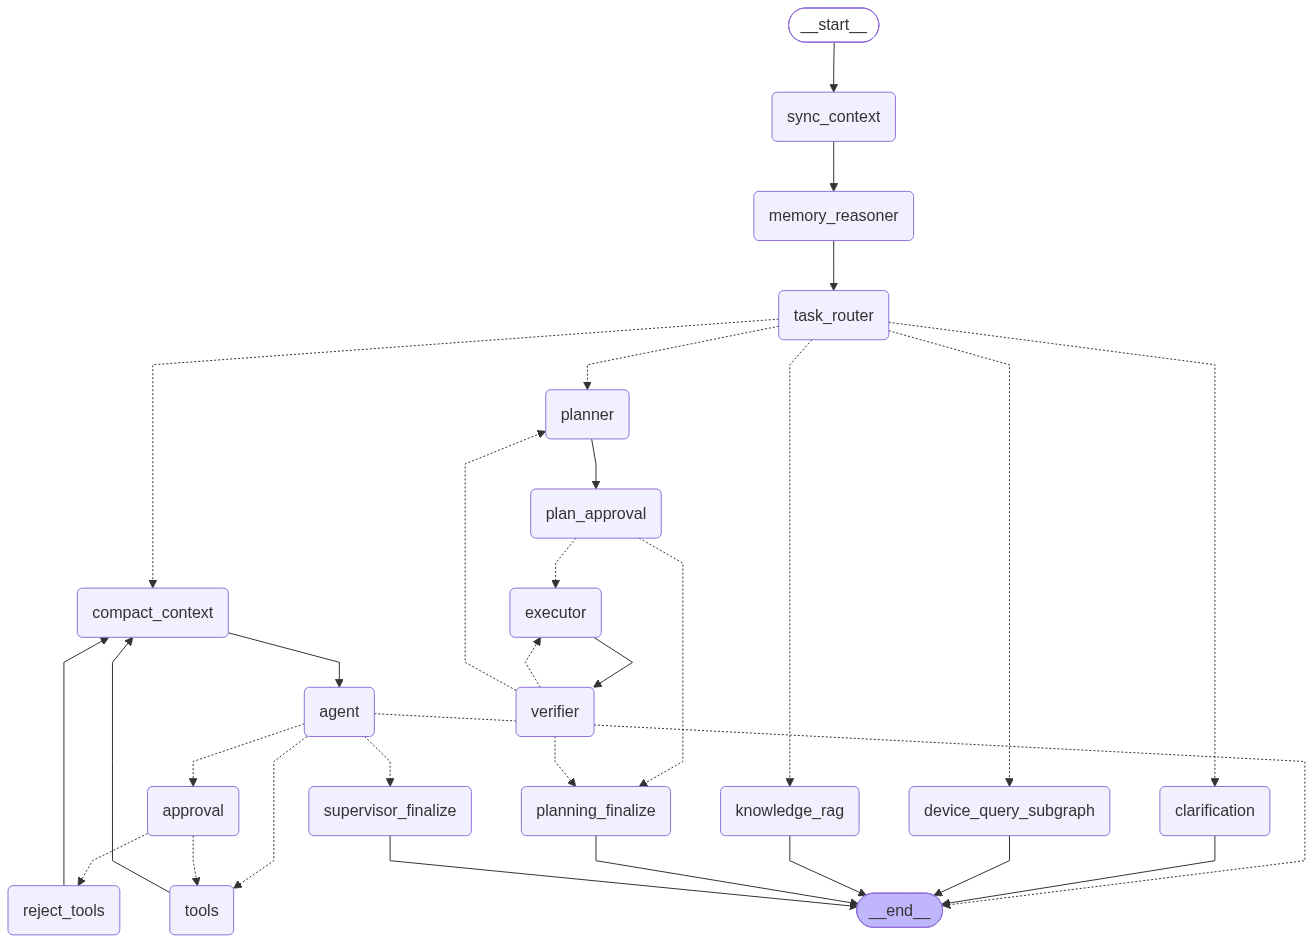

In [27]:
out_path = PROJECT_ROOT / 'docs' / 'agent_workflow_official.png'
out_path.parent.mkdir(parents=True, exist_ok=True)

try:
    png_bytes = drawable.draw_mermaid_png()
    out_path.write_bytes(png_bytes)
    print(f'已保存: {out_path}  ({len(png_bytes) / 1024:.1f} KB)')
    display(Image(data=png_bytes))
except Exception as exc:
    print('draw_mermaid_png 失败（通常是网络或缺少 pyppeteer），回退到手写渲染。')
    print('原因:', exc)
    render_mermaid_png(official_mermaid, out_path)

## 总结

这个 Notebook 提供了三种可视化方式：

1. **简化版**（最初的几格）：只展示 `agent` + `tools` 的核心循环，适合快速理解基本原理
2. **手写完整版**（分层 Mermaid）：按功能分组展示所有节点和路径，便于理解整体架构
3. **权威版**（LangGraph 导出）：直接从 `build_graph()` 生成，保证和运行时完全一致

**典型执行路径验证**：对照日志排查时，可以参考"典型请求的执行路径"部分。

**导出文件**：
- `docs/agent_workflow.png`：手写版本（分层清晰）
- `docs/agent_workflow_official.png`：LangGraph 官方版本（拓扑精确）

这两个文件可直接用于文档、PPT 或设计评审。